# TODO
- Read annotation file to dataframe
- check amount of events per label
- make a selection of 1000 events from this set 
- for each event plot the spectrogram and only save those that make sense
- calculate masks for each of these events 
- 

In [2]:
import pandas as pd
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
import pathlib

%matplotlib widget

In [3]:
def moc_path(path):
    if not isinstance(path, str):
        return ""
    elif path.begins_with("D:\data"):
        return path.replace("D:\data", "//mnt/fscompute_shared").replace("\\", "/")
    return path.replace(
        "\\\\qarchive\\data_sensors", "//mnt/qarchive_data_sensors"
    ).replace("\\", "/")


def plot_row_event(row):
    data, fs = sf.read(row["Path"])
    fig, ax = plt.subplots()
    start_sample = row["Beg File Samp (samples)"]
    end_sample = int(row["End File Samp (samples)"])
    __, __, Spect = spectrogram(
        data[start_sample:end_sample], fs, nperseg=256, noverlap=128
    )

    ax.pcolormesh(np.log10(np.abs(Spect)))
    plt.show()

# Step 1: Get information on the labeled set

In [4]:
annotation_location = "/mnt/fs_shared/onderzoek/6. Marine Observation Center/Projects/SoundLib_VLIZ2024/sound_db/sound_bpns/selection_tables/all_annotations.csv"
df = pd.read_csv(annotation_location)
df["Path"] = df["Begin Path"].apply(moc_path)

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/fs_shared/onderzoek/6. Marine Observation Center/Projects/SoundLib_VLIZ2024/sound_db/sound_bpns/selection_tables/all_annotations.csv'

In [4]:
balance = np.ceil(
    df["Label"].value_counts() / df["Label"].value_counts().sum() * 1000
).astype(int)
print(balance)

Label
crustacean_stridulation    241
impulsive_poc              115
impulsive_click             72
impulsive_clack             67
whistling                   57
                          ... 
water_sound                  1
boat_sound                   1
snitch                       1
electronic_impact            1
fish                         1
Name: count, Length: 82, dtype: int64


# Step 2: plot the spectrogram of one event 

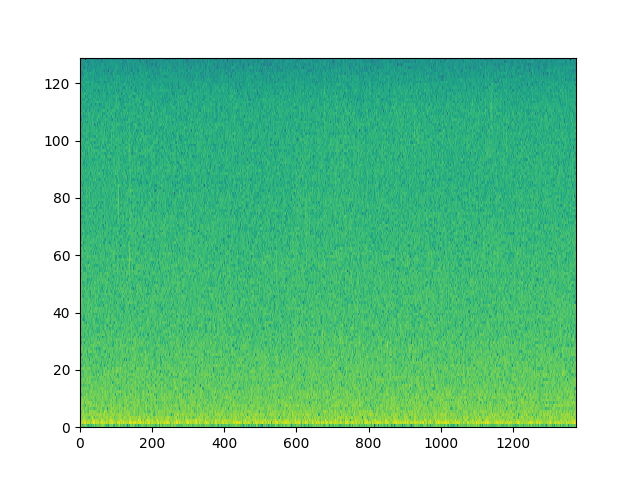

In [5]:
row = df.iloc[0]
plot_row_event(row)
# data, fs = sf.read(row['Path'])
# fig, ax = plt.subplots()
# start_sample = row['Beg File Samp (samples)']
# end_sample = int(row['End File Samp (samples)'])
# __,__, Spect = spectrogram(data[start_sample: end_sample], fs, nperseg=256, noverlap=128)

# ax.pcolormesh(np.log10(np.abs(Spect)))

In [8]:
# take one row and plot the spectrogram of the sound file for the time the event is active
row = df.iloc[0]
print(row)
print(row["Label"])
print(row["Begin Path"])
print(row["Begin Time (s)"])
print(row["End Time (s)"])

Selection                                                                  1
View                                                           Spectrogram 1
Channel                                                                    1
Begin Time (s)                                                  80348.466528
End Time (s)                                                     80352.13596
Delta Time (s)                                                        3.6694
Low Freq (Hz)                                                           87.0
High Freq (Hz)                                                         579.7
Beg File Samp (samples)                                             27662713
End File Samp (samples)                                             27838846
Begin Clock Time                                               22:19:28.4665
Begin Date                                                        2022-01-26
SNR NIST Quick (dB)                                                    14.75

In [8]:
stringpath = "\\\\qarchive\\data_sensors\\rtsys\\PhD_Clea\\Buitenratel_20220119\\records\\220126\\channelA_2022-01-26_22-09-52.wav"
stringpath = stringpath.replace(
    "\\\\qarchive\\data_sensors", "//mnt/qarchive_data_sensors"
)
stringpath = stringpath.replace("\\", "/")
print(stringpath)

//mnt/qarchive_data_sensors/rtsys/PhD_Clea/Buitenratel_20220119/records/220126/channelA_2022-01-26_22-09-52.wav


In [18]:
def filter(x):
    if not isinstance(x, str):
        return False
    if x.startswith("D:\\"):
        return True
    return False


filtering = df["Begin Path"].apply(filter)

In [19]:
df[filtering]

,Selection,View,Channel,Begin Time (s),End Time (s),Delta Time (s),Low Freq (Hz),High Freq (Hz),Beg File Samp (samples),End File Samp (samples),...,Peak Freq (Hz),Begin File,Begin Path,Label,Source,user,Comments,PFC Avg Slope (Hz/ms),path original file,Path
661,662,Spectrogram 1,1,35.418833,35.557083,0.1382,8351.358,11083.698,850052,853370,...,10500.000,channelAC_2021-03-10_02-29-20.wav,D:\data\roi\datasets\bpns\stratified_test_set\...,NaN,NaN,NaN,NaN,NaN,\\qarchive\data_sensors\rtsys\PhD_Clea\Faulbau...,D:/data/roi/datasets/bpns/stratified_test_set/...
662,663,Spectrogram 1,1,190.366458,190.554958,0.1885,3032.258,6322.581,4568795,4573319,...,3093.750,channelAC_2021-03-10_02-29-20.wav,D:\data\roi\datasets\bpns\stratified_test_set\...,NaN,NaN,NaN,NaN,NaN,\\qarchive\data_sensors\rtsys\PhD_Clea\Faulbau...,D:/data/roi/datasets/bpns/stratified_test_set/...
663,664,Spectrogram 1,1,92.414417,92.560167,0.1458,7221.126,11154.882,2217946,2221444,...,8906.250,channelAC_2021-03-10_02-29-20.wav,D:\data\roi\datasets\bpns\stratified_test_set\...,NaN,NaN,NaN,NaN,NaN,\\qarchive\data_sensors\rtsys\PhD_Clea\Faulbau...,D:/data/roi/datasets/bpns/stratified_test_set/...
664,665,Spectrogram 1,1,43.717250,43.926667,0.2094,3612.903,10967.742,1049214,1054240,...,5859.375,channelAC_2021-03-10_02-29-20.wav,D:\data\roi\datasets\bpns\stratified_test_set\...,NaN,NaN,NaN,NaN,NaN,\\qarchive\data_sensors\rtsys\PhD_Clea\Faulbau...,D:/data/roi/datasets/bpns/stratified_test_set/...
665,666,Spectrogram 1,1,166.249750,166.443833,0.1941,6677.532,11823.252,3989994,3994652,...,7687.500,channelAC_2021-03-10_02-29-20.wav,D:\data\roi\datasets\bpns\stratified_test_set\...,NaN,NaN,NaN,NaN,NaN,\\qarchive\data_sensors\rtsys\PhD_Clea\Faulbau...,D:/data/roi/datasets/bpns/stratified_test_set/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23532,23533,Spectrogram 1,1,27791.643340,27791.758300,0.1150,2066.667,9266.667,4897808,4900567,...,2109.375,channelA_2021-04-02_18-15-56.wav,D:\data\roi\datasets\bpns\stratified_test_set\...,jingle_bell,NaN,Julia Aubach,NaN,NaN,\\qarchive\data_sensors\rtsys\PhD_Clea\Grafton...,D:/data/roi/datasets/bpns/stratified_test_set/...
23533,23534,Spectrogram 1,1,42103.241270,42103.383990,0.1427,1648.352,3032.967,9651294,9654720,...,2343.750,channelA_2022-02-21_14-50-07.wav,D:\data\roi\datasets\bpns\stratified_test_set\...,jingle_bell,NaN,Julia Aubach,NaN,NaN,\\qarchive\data_sensors\rtsys\PhD_Clea\Grafton...,D:/data/roi/datasets/bpns/stratified_test_set/...
23534,23535,Spectrogram 1,1,49786.665280,49786.720780,0.0555,606.742,2359.551,2600287,2601619,...,1312.500,channelA_2022-04-06_01-32-25.wav,D:\data\roi\datasets\bpns\stratified_test_set\...,NaN,NaN,Julia Aubach,NaN,NaN,\\qarchive\data_sensors\rtsys\PhD_Clea\Grafton...,D:/data/roi/datasets/bpns/stratified_test_set/...
23535,23536,Spectrogram 1,1,51232.238400,51232.476250,0.2378,6745.946,8562.162,7839706,7845414,...,7968.750,channelA_2022-04-12_21-18-44.wav,D:\data\roi\datasets\bpns\stratified_test_set\...,chain_bell,NaN,Julia Aubach,NaN,NaN,\\qarchive\data_sensors\rtsys\PhD_Clea\Buitenr...,D:/data/roi/datasets/bpns/stratified_test_set/...


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from dearpygui import dearpygui as dpg


# Function to display a plot for a given row
def plot_row(row):
    plt.figure()
    plt.title(f"Row Index: {row.Label}")
    data, fs = sf.read(row["Path"])
    start_sample = row["Beg File Samp (samples)"]
    end_sample = int(row["End File Samp (samples)"])
    __, __, Spect = spectrogram(
        data[start_sample:end_sample], fs, nperseg=256, noverlap=128
    )
    plt.imshow(np.log10(np.abs(Spect)))
    plt.show()


def interactive_row_filter(df):
    """
    Loops through rows of a dataframe, displays a plot for each row, and
    allows the user to decide whether to keep the row or skip it.

    Args:
        df (pd.DataFrame): The input dataframe.

    Returns:
        pd.DataFrame: A new dataframe containing only the rows the user chose to keep.
    """
    selected_rows = []

    for idx, row in df.iterrows():
        # Display the plot for the current row
        plot_row(row)

        # Ask the user if they want to keep the row
        while True:
            user_input = input(f"Keep row {idx}? (y/n): ").strip().lower()
            if user_input in ("y", "n"):
                break
            else:
                print("Invalid input. Please enter 'y' to keep or 'n' to skip.")

        # Append the row index if the user chooses to keep it
        if user_input == "y":
            selected_rows.append(idx)

    # Create a new dataframe with only the selected rows
    return df.loc[selected_rows]


# Example usage (assuming 'your_dataframe' is a predefined DataFrame)
# filtered_df = interactive_row_filter_gui(your_dataframe)
# print(filtered_df)

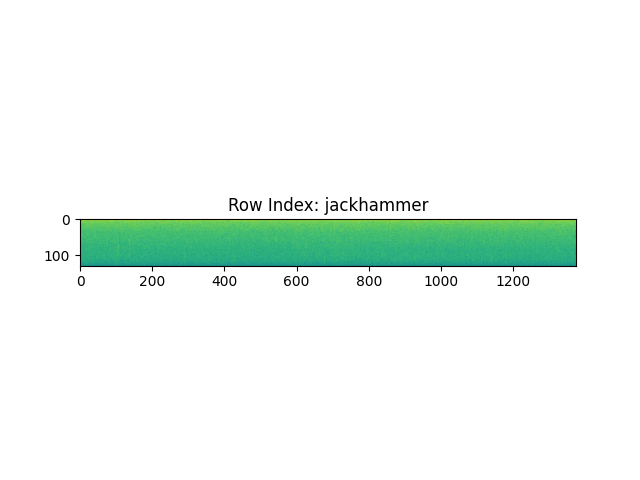

/tmp/ipykernel_651260/3962194955.py:12: UserWarning: nperseg = 256 is greater than input length  = 0, using nperseg = 0
  __,__, Spect = spectrogram(data[start_sample: end_sample], fs, nperseg=256, noverlap=128)


TypeError: Invalid shape (0,) for image data

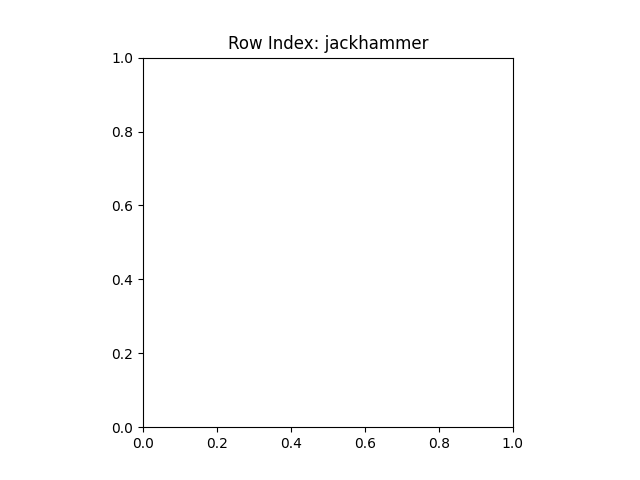

In [14]:
filtered_df = interactive_row_filter(df)

In [ ]:
folder = pathlib.Path("/data/bram.cuyx/Gitlab/uw-sim/chosen_rows")
all_anns = pd.DataFrame()
for f in folder.glob("*annotations*.pkl"):
    pd_df = pd.read_pickle(f)
    all_anns = pd.concat([all_anns, pd_df], ignore_index=True)

all_anns[["Label", "Source", "Classification"]]

,Label,Source,Classification
0,jackhammer,fish_jackhammer,NaN
1,jackhammer,fish_jackhammer,NaN
2,jackhammer,fish_jackhammer,NaN
3,jackhammer,fish_jackhammer,NaN
4,jackhammer,fish_jackhammer,NaN
...,...,...,...
211,NaN,NaN,NaN
212,knock,unknown,unknown
213,metallic_bell,unknown,unknown
214,impulsive_poc,unknown,unknown


In [32]:
folder = pathlib.Path("/data/bram.cuyx/Gitlab/uw-sim/chosen_rows")
all_back = pd.DataFrame()
for f in folder.glob("*background*.pkl"):
    pd_df = pd.read_pickle(f)
    all_back = pd.concat([all_back, pd_df], ignore_index=True)

all_back

,Path,Begin Time background (s),End Time background (s)
0,/mnt/qarchive_data_sensors/rtsys/PhD_Clea/Buit...,0.000000,10.000000
1,/mnt/qarchive_data_sensors/rtsys/PhD_Clea/Graf...,35.522896,45.522896
2,/mnt/qarchive_data_sensors/soundtrap/broadband...,0.000000,10.000000
3,/mnt/qarchive_data_sensors/rtsys/PhD_Clea/Buit...,0.000000,10.000000
4,/mnt/qarchive_data_sensors/rtsys/PhD_Clea/Buit...,245.000000,255.000000
...,...,...,...
98,/mnt/qarchive_data_sensors/rtsys/PhD_Clea/Graf...,521.994208,531.994208
99,/mnt/qarchive_data_sensors/rtsys/PhD_Clea/Birk...,0.000000,10.000000
100,/mnt/qarchive_data_sensors/rtsys/PhD_Clea/Buit...,410.000000,420.000000
101,/mnt/qarchive_data_sensors/rtsys/PhD_Clea/Buit...,348.098875,358.098875


In [14]:
pd.read_pickle(
    "/data/bram.cuyx/Gitlab/uw-sim/chosen_rows/filtered_background_20250122_174903.pkl"
)

,Path,Begin Time background (s),End Time background (s)


In [15]:
pd.read_csv(
    "/mnt/fs_shared/onderzoek/6. Marine Observation Center/Projects/SoundLib_VLIZ2024/sound_db/sound_bpns/selection_tables/all_annotations.csv"
)

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/fs_shared/onderzoek/6. Marine Observation Center/Projects/SoundLib_VLIZ2024/sound_db/sound_bpns/selection_tables/all_annotations.csv'

In [19]:
selection_table = (
    "/mnt/fscompute_shared/sound_classification/total_selections_linux.pkl"
)
select_df = pd.read_pickle(
    selection_table,
)
select_df.columns

Index(['Delta Time (s)', 'Low Freq (Hz)', 'High Freq (Hz)', 'Peak Freq (Hz)',
       'SNR NIST Quick (dB)', 'Begin Time (s)', 'End Time (s)', 'Begin File',
       'Label', 'Source', 'Comments', 'Classification',
       'assumed_Classification', 'assumed_Source', 'user', 'class_status',
       'doubtful_example', 'selection_table', 'deployment', 'Selection',
       'audio_path', 'image_path', 'Begin Path'],
      dtype='object')

In [20]:
select_df["Begin Time (s)"]

0        364317.935994
1        364415.335175
2        364836.683265
3        364837.809206
4        364838.998638
             ...      
16778    653058.761822
16779    632087.158356
16780    652259.254685
16781    652282.713599
16782    652318.802420
Name: Begin Time (s), Length: 16783, dtype: float64

In [28]:
sel = "/mnt/fs_shared/onderzoek/6. Marine Observation Center/Projects/SoundLib_VLIZ2024/sound_db/sound_bpns/selection_tables/Selection___qarchive_data_sensors_rtsys_PhD_Clea_Grafton_20221027_records_221107.txt"
table = pd.read_table(sel)

In [29]:
table.columns

Index(['Selection', 'View', 'Channel', 'Begin Time (s)', 'End Time (s)',
       'Delta Time (s)', 'Low Freq (Hz)', 'High Freq (Hz)',
       'Beg File Samp (samples)', 'End File Samp (samples)',
       'Begin Clock Time', 'Begin Date', 'SNR NIST Quick (dB)',
       'Peak Freq (Hz)', 'Begin File', 'Begin Path', 'End File', 'End Path',
       'Label', 'user', 'Comments', 'Bell_type', 'assumed_Classification',
       'assumed_Source', 'Classification', 'Source'],
      dtype='object')

In [30]:
1668981 / 48000

34.7704375